# BeetleCast — Run Me First

This notebook is designed for this project structure:

```text
project_root/
├── pyproject.toml
├── uv.lock
├── hackathon_data/
│   ├── raw/
│   │   ├── sentinel2/
│   │   ├── aef_embeddings/
│   │   └── useful-data/
│   └── processed/
│       └── labels/
│           └── F3_bark_beetle_labels_in_aoi.gpkg
├── notebooks/
│   └── 00_beetlecast_run_me.ipynb
└── outputs/
```

Launch Jupyter from `project_root`, then open this notebook from `notebooks/`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr

warnings.filterwarnings("ignore")

# Robustly detect project root whether Jupyter starts in project_root or notebooks/
cwd = Path.cwd()

if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find hackathon_data/. "
        "Launch Jupyter from your project root, or place this notebook in project_root/notebooks/."
    )

DATA_ROOT = PROJECT_ROOT / "hackathon_data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RAW_ROOT:", RAW_ROOT)
print("PROCESSED_ROOT:", PROCESSED_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
DATA_ROOT: /Users/hemat/Desktop/hackathon-demo/hackathon_data
RAW_ROOT: /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw
PROCESSED_ROOT: /Users/hemat/Desktop/hackathon-demo/hackathon_data/processed
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs


## 1. Check the expected folders

In [2]:
for path in [DATA_ROOT, RAW_ROOT, PROCESSED_ROOT]:
    print(f"{path}: {'OK' if path.exists() else 'MISSING'}")


/Users/hemat/Desktop/hackathon-demo/hackathon_data: OK
/Users/hemat/Desktop/hackathon-demo/hackathon_data/raw: OK
/Users/hemat/Desktop/hackathon-demo/hackathon_data/processed: MISSING


## 2. Find the Sentinel-2 Zarr cube

In [3]:
zarr_paths = list(RAW_ROOT.rglob("cube.zarr"))

print(f"Found {len(zarr_paths)} cube.zarr directories:")
for i, path in enumerate(zarr_paths, start=1):
    print(f"{i}. {path}")

assert zarr_paths, (
    "No cube.zarr found under hackathon_data/raw. "
    "Check where you copied the extracted Sentinel-2 folder."
)

# Prefer the F3 bark-beetle cube when multiple cubes exist.
f3_candidates = [
    p for p in zarr_paths
    if "f3" in str(p).lower()
    or "bark" in str(p).lower()
    or "germany" in str(p).lower()
]

CUBE_PATH = f3_candidates[0] if f3_candidates else zarr_paths[0]
print("\nUsing:", CUBE_PATH)


Found 1 cube.zarr directories:
1. /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/sentinal2/sentinel2/F3_Germany_BarkBeetle/2017-01-01_2025-12-31/cube.zarr

Using: /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/sentinal2/sentinel2/F3_Germany_BarkBeetle/2017-01-01_2025-12-31/cube.zarr


## 3. Open Sentinel-2 lazily

In [4]:
ds = xr.open_zarr(CUBE_PATH, chunks="auto")

print(ds)
print("\nDimensions:", dict(ds.sizes))
print("Variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

if "time" in ds.coords:
    print("Time range:", ds.time.min().values, "to", ds.time.max().values)


<xarray.Dataset> Size: 3GB
Dimensions:      (time: 108, y: 1262, x: 1065)
Coordinates:
  * time         (time) datetime64[ns] 864B 2017-01-01 2017-02-01 ... 2025-12-01
  * y            (y) float64 10kB 5.512e+06 5.512e+06 ... 5.499e+06 5.499e+06
  * x            (x) float64 9kB 3.546e+05 3.546e+05 ... 3.652e+05 3.652e+05
    spatial_ref  int64 8B ...
Data variables:
    B02          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B03          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B04          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B05          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B06          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B07          (time, y, x) uint16 290MB dask.array<chunksize=(49, 1262, 1065), meta=np.ndarray>
    B08          (time, y, x) uint16 

## 4. Find and load the cleaned bark-beetle labels

In [5]:
# First prefer the cleaned GeoPackage anywhere in the project.
label_candidates = list(
    PROJECT_ROOT.rglob("F3_bark_beetle_labels_in_aoi.gpkg")
)

# Otherwise find any likely original bark-beetle vector file.
if not label_candidates:
    label_candidates = [
        p for p in PROJECT_ROOT.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {".gpkg", ".geojson"}
        and (
            "bark_beetle" in p.name.lower()
            or "bark_bettle" in p.name.lower()
            or ("bark" in p.name.lower() and "beetle" in p.name.lower())
            or ("bark" in p.name.lower() and "bettle" in p.name.lower())
        )
        and "aoi" not in p.name.lower()
    ]

print(f"Found {len(label_candidates)} possible label file(s):")
for i, path in enumerate(label_candidates, start=1):
    print(f"{i}. {path}")

assert label_candidates, (
    "No bark-beetle label GeoJSON or GeoPackage was found anywhere under the project root. "
    "Download F3_bark_beetle_locations.geojson and put it anywhere under hackathon_data/raw/ "
    "or put F3_bark_beetle_labels_in_aoi.gpkg under hackathon_data/processed/labels/."
)

LABEL_PATH = label_candidates[0]
print("\nUsing:", LABEL_PATH)

if LABEL_PATH.suffix.lower() == ".gpkg":
    try:
        labels = gpd.read_file(LABEL_PATH, layer="bark_beetle_labels")
    except Exception:
        labels = gpd.read_file(LABEL_PATH)
else:
    labels = gpd.read_file(LABEL_PATH)

# Add the year from tile_name when needed.
if "label_year" not in labels.columns and "tile_name" in labels.columns:
    labels["label_year"] = (
        labels["tile_name"]
        .astype(str)
        .str.extract(r"_rp_(20\d{2})_")[0]
        .astype("Int64")
    )

# If this is the original full file, clip it to the AOI when an AOI is available.
if "in_aoi" not in LABEL_PATH.stem.lower():
    aoi_candidates_for_clip = [
        p for p in PROJECT_ROOT.rglob("*.geojson")
        if "aoi" in p.name.lower()
        and ("f3" in p.name.lower() or "germany" in p.name.lower() or "bark" in p.name.lower())
    ]

    if aoi_candidates_for_clip:
        aoi_for_clip = gpd.read_file(aoi_candidates_for_clip[0])
        labels = labels.to_crs(aoi_for_clip.crs)
        labels["geometry"] = labels.geometry.make_valid()
        labels = gpd.clip(labels, aoi_for_clip)
        labels = labels[~labels.geometry.is_empty].copy()

        # Save a cleaned copy for future runs.
        cleaned_dir = PROCESSED_ROOT / "labels"
        cleaned_dir.mkdir(parents=True, exist_ok=True)
        cleaned_path = cleaned_dir / "F3_bark_beetle_labels_in_aoi.gpkg"
        labels.to_file(
            cleaned_path,
            layer="bark_beetle_labels",
            driver="GPKG",
        )
        LABEL_PATH = cleaned_path
        print("Created cleaned label file:", cleaned_path)
    else:
        print(
            "Original labels loaded, but no AOI boundary was found for clipping. "
            "The notebook will continue with the full label file."
        )

print("Rows:", len(labels))
print("CRS:", labels.crs)
print("Columns:", list(labels.columns))
display(labels.head())


Found 1 possible label file(s):
1. /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.gpkg

Using: /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.gpkg
Rows: 3014
CRS: EPSG:4326
Columns: ['tile_name', 'label_year', 'area_ha', 'clipped_area_ha', 'geometry']


,tile_name,label_year,area_ha,clipped_area_ha,geometry
0,dop20rgbi_32_354_5502_2_rp_2023_001_016,2023,0.146723,0.146723,"MULTIPOLYGON (((6.99869 49.67052, 6.99868 49.6..."
1,dop20rgbi_32_354_5502_2_rp_2023_001_017,2023,0.237213,0.237213,"MULTIPOLYGON (((6.99923 49.67113, 6.99923 49.6..."
2,dop20rgbi_32_354_5502_2_rp_2023_002_015,2023,0.059728,0.059728,"MULTIPOLYGON (((6.99734 49.67001, 6.99736 49.6..."
3,dop20rgbi_32_354_5502_2_rp_2023_002_016,2023,0.017023,0.017023,"MULTIPOLYGON (((6.99736 49.66963, 6.99734 49.6..."
4,dop20rgbi_32_354_5502_2_rp_2023_002_017,2023,0.015008,0.015008,"MULTIPOLYGON (((6.99993 49.6695, 6.99996 49.66..."


## 5. Load the AOI boundary if present

In [6]:
aoi_candidates = [
    p for p in DATA_ROOT.rglob("*.geojson")
    if "aoi" in p.name.lower()
    and ("f3" in p.name.lower() or "germany" in p.name.lower() or "bark" in p.name.lower())
]

print(f"Found {len(aoi_candidates)} AOI candidate(s):")
for i, path in enumerate(aoi_candidates, start=1):
    print(f"{i}. {path}")

aoi = None
if aoi_candidates:
    AOI_PATH = aoi_candidates[0]
    aoi = gpd.read_file(AOI_PATH)
    print("Using:", AOI_PATH)
    print("AOI CRS:", aoi.crs)
    print("AOI rows:", len(aoi))
else:
    print("No AOI GeoJSON found. The notebook can continue without it for now.")


Found 1 AOI candidate(s):
1. /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.geojson
Using: /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.geojson
AOI CRS: EPSG:4326
AOI rows: 3014


## 6. Clean Sentinel-2 and calculate NDVI/NDRE

The hackathon Sentinel-2 data has an artificial `+1000 DN` step from 2022-01-25 onward.  
This function masks `n_obs == 0`, corrects the baseline shift, clamps at zero, and converts to reflectance.


In [7]:
required = {"B04", "B05", "B08"}
missing = required - set(ds.data_vars)

if missing:
    raise KeyError(f"Missing required Sentinel-2 bands: {missing}")

def clean_reflectance_band(ds, band):
    x = ds[band].astype("float32")

    if "n_obs" in ds.data_vars:
        x = x.where(ds["n_obs"] > 0)

    if "time" in ds.coords:
        cutoff = np.datetime64("2022-01-25")
        x = xr.where(
            ds.time >= cutoff,
            xr.where(x >= 1000, x - 1000, 0),
            x,
        )

    return x / 10000.0

red = clean_reflectance_band(ds, "B04")
red_edge = clean_reflectance_band(ds, "B05")
nir = clean_reflectance_band(ds, "B08")

ndvi = (nir - red) / (nir + red)
ndre = (nir - red_edge) / (nir + red_edge)

print("NDVI:", ndvi)
print("NDRE:", ndre)


NDVI: <xarray.DataArray 'time' (time: 108, y: 1262, x: 1065)> Size: 581MB
dask.array<truediv, shape=(108, 1262, 1065), dtype=float32, chunksize=(49, 1262, 1065), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 864B 2017-01-01 2017-02-01 ... 2025-12-01
  * y            (y) float64 10kB 5.512e+06 5.512e+06 ... 5.499e+06 5.499e+06
  * x            (x) float64 9kB 3.546e+05 3.546e+05 ... 3.652e+05 3.652e+05
    spatial_ref  int64 8B ...
Attributes:
    resolution:  10
NDRE: <xarray.DataArray 'time' (time: 108, y: 1262, x: 1065)> Size: 581MB
dask.array<truediv, shape=(108, 1262, 1065), dtype=float32, chunksize=(49, 1262, 1065), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 864B 2017-01-01 2017-02-01 ... 2025-12-01
  * y            (y) float64 10kB 5.512e+06 5.512e+06 ... 5.499e+06 5.499e+06
  * x            (x) float64 9kB 3.546e+05 3.546e+05 ... 3.652e+05 3.652e+05
    spatial_ref  int64 8B ...
Attributes:
    resolution:  10


## 7. Run a small sample only

Sample shape: (200, 200)
Sample minimum: nan
Sample maximum: nan


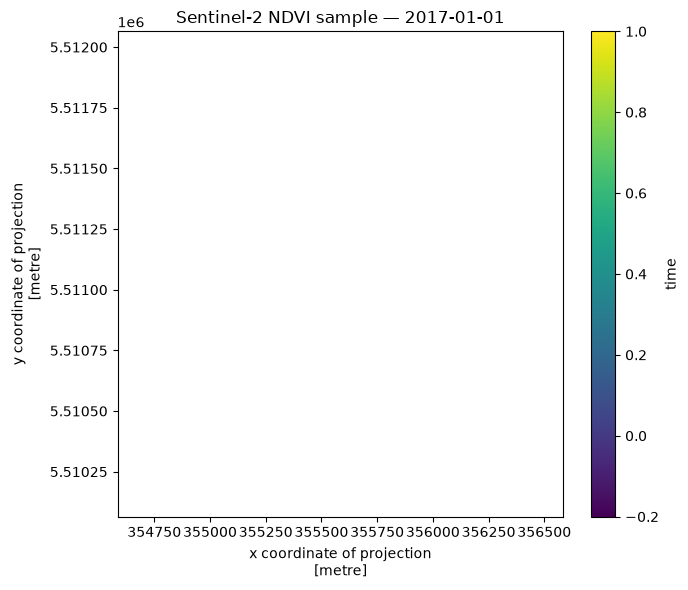

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/sentinel2_ndvi_sample.png


In [8]:
sample_ndvi = ndvi.isel(
    time=0,
    y=slice(0, min(200, ndvi.sizes["y"])),
    x=slice(0, min(200, ndvi.sizes["x"])),
).compute()

print("Sample shape:", sample_ndvi.shape)
print("Sample minimum:", float(sample_ndvi.min(skipna=True)))
print("Sample maximum:", float(sample_ndvi.max(skipna=True)))

sample_ndvi.plot(figsize=(7, 6), vmin=-0.2, vmax=1.0)
plt.title(f"Sentinel-2 NDVI sample — {pd.to_datetime(ds.time.values[0]).date()}")
plt.tight_layout()

sample_plot = OUTPUT_ROOT / "sentinel2_ndvi_sample.png"
plt.savefig(sample_plot, dpi=180)
plt.show()

print("Saved:", sample_plot)


## 8. Inspect label years

In [9]:
if "label_year" in labels.columns:
    print(labels["label_year"].value_counts(dropna=False).sort_index())
else:
    print("No label_year column found.")
    if "tile_name" in labels.columns:
        labels["label_year"] = (
            labels["tile_name"]
            .astype(str)
            .str.extract(r"_rp_(20\d{2})_")[0]
            .astype("Int64")
        )
        print(labels["label_year"].value_counts(dropna=False).sort_index())


label_year
2022    1583
2023    1431
Name: count, dtype: int64


## 9. Final status

In [10]:
print("READY CHECK")
print("Sentinel-2 cube:", "OK" if CUBE_PATH.exists() else "MISSING")
print("Cleaned labels:", "OK" if LABEL_PATH.exists() else "MISSING")
print("NDVI/NDRE computed:", "OK")
print("Output folder:", OUTPUT_ROOT)

print(
    "\nNext step: build a forest-only patch grid, generate positive and negative samples, "
    "and create the first real gradient-boost baseline."
)


READY CHECK
Sentinel-2 cube: OK
Cleaned labels: OK
NDVI/NDRE computed: OK
Output folder: /Users/hemat/Desktop/hackathon-demo/outputs

Next step: build a forest-only patch grid, generate positive and negative samples, and create the first real gradient-boost baseline.
